In [3]:
"""
Mean-Field MCMC (particle system) in JAX for the McKean–Vlasov CTMC described.

Rather than integrating the gradient-flow ODE for p_t, we simulate an
interacting particle Markov chain whose one-step transition targets the
law-dependent "Gibbs" measure

    π_p(x) ∝ p0(x) * exp( Σ_i p_i(x) / m_i(p) ),  with  m_i(p) = Σ_x p_i(x) p(x)

where p is the current empirical measure of the particle system.

Algorithm (synchronous scan per iteration):
  1) Form empirical \hat p from current particle states {X_j}.
  2) Compute log π_{\hat p} using the likelihood table L and prior p0.
  3) For each particle j with current state x, propose y ~ q(y|x) ∝ A[x, y].
  4) Accept with prob α = min{1, π_{\hat p}(y) / π_{\hat p}(x)} (Metropolis-within-graph).

This is a mean-field MCMC because each particle's acceptance ratio depends on
the current empirical \hat p through the π_{\hat p} term. In the large-N limit,
its marginal law approximates the nonlinear Kolmogorov forward equation.

The code provides:
  - Problem container (p0, likelihoods L, symmetric adjacency A)
  - Stable computation of log π_{p}
  - Vectorised one-step update over all particles (JIT + vmap friendly)
  - A driver to run T iterations and (optionally) track the free-energy F(\hat p)
  - A small 1D demo on a line graph with Gaussian-like likelihoods

Author: (you + ChatGPT)
"""
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple

import jax
import jax.numpy as jnp

Array = jnp.ndarray


def _eps(dtype=jnp.float32) -> float:
    return 1e-12 if dtype == jnp.float32 else 1e-15


@dataclass
class MFProblem:
    """Problem data.

    p0: (M,) strictly positive prior, sums to 1
    L : (n, M) with L[i, x] = p_i(x) = p(y_i | x) (only positivity matters)
    A : (M, M) symmetric nonnegative adjacency weights a_{x,y}, zero diagonal
    """

    p0: Array
    L: Array
    A: Array

    def __post_init__(self):
        M = self.p0.shape[0]
        assert self.L.shape[1] == M, "L must have shape (n, M)"
        assert self.A.shape == (M, M), "A must be (M, M)"
        if not jnp.all(self.p0 > 0):
            raise ValueError("p0 must be strictly positive")
        if not jnp.allclose(self.A, self.A.T):
            raise ValueError("A must be symmetric")
        if not jnp.all(jnp.diag(self.A) == 0):
            raise ValueError("A must have zero diagonal (no self-proposals)")


@dataclass
class MFMCMC:
    problem: MFProblem
    alpha_smooth: float = 1e-6  # Dirichlet smoothing for \hat p
    eps: float = 1e-12

    # ----------------------- Core mean-field quantities ---------------------- #

    def m(self, p: Array) -> Array:
        """m_i(p) = Σ_x L[i, x] p(x). Shape (n,)."""
        return self.problem.L @ p

    def log_pi(self, p: Array) -> Array:
        """log π_p(x) = log p0(x) + Σ_i L[i,x] / m_i(p). Shape (M,)."""
        m = jnp.clip(self.m(p), self.eps, None)  # (n,)
        contrib = (self.problem.L / m[:, None]).sum(axis=0)  # (M,)
        return jnp.log(jnp.clip(self.problem.p0, self.eps, None)) + contrib

    def free_energy(self, p: Array) -> Array:
        """F(p) = KL(p||p0) - Σ_i log m_i(p)."""
        p = jnp.clip(p, self.eps, None)
        kld = jnp.sum(p * (jnp.log(p) - jnp.log(jnp.clip(self.problem.p0, self.eps, None))))
        m = jnp.clip(self.m(p), self.eps, None)
        L_term = -jnp.sum(jnp.log(m))
        return kld + L_term

    # ----------------------- Proposals and one-step update ------------------- #

    def _proposal_logits(self) -> Array:
        """Row-wise logits for q(y|x) ∝ A[x, y]."""
        # Replace zeros with -inf so categorical never picks them
        logits = jnp.where(self.problem.A > 0, jnp.log(self.problem.A), -jnp.inf)
        return logits

    def empirical_p(self, states: Array) -> Array:
        """Compute empirical measure with Dirichlet smoothing.

        states: (N,) integer state indices in {0,...,M-1}
        returns p_hat: (M,)
        """
        M: int = int(self.problem.p0.shape[0])
        # Use a *static* length for jnp.bincount to avoid ConcretizationTypeError under jit/scan
        counts = jnp.bincount(states, length=M)
        N = states.shape[0]
        p_hat = (counts + self.alpha_smooth) / (N + M * self.alpha_smooth)
        return p_hat

    def step(self, key: Array, states: Array) -> Tuple[Array, Array, Array]:
        """One synchronous MF-MCMC sweep over all particles.

        key: PRNGKey
        states: (N,)
        returns (new_states, p_hat_new, log_pi_p)
        """
        logits = self._proposal_logits()  # (M, M)
        p_hat = self.empirical_p(states)  # (M,)
        log_pi_p = self.log_pi(p_hat)     # (M,)

        # Propose y for each particle from q(·|x)
        key_prop, key_acc = jax.random.split(key)
        logits_rows = logits[states]  # (N, M)
        y = jax.random.categorical(key_prop, logits_rows)  # (N,)

        # Metropolis acceptance targeting π_p
        log_acc_ratio = log_pi_p[y] - log_pi_p[states]
        log_u = jnp.log(jax.random.uniform(key_acc, shape=states.shape))
        accept = log_u < jnp.minimum(0.0, log_acc_ratio)
        new_states = jnp.where(accept, y, states)

        p_hat_new = self.empirical_p(new_states)
        return new_states, p_hat_new, log_pi_p

    # ---------------------------- Driver / run loop -------------------------- #

    def run(self, key: Array, states0: Array, n_steps: int) -> Tuple[Array, Array, Array]:
        """Run n_steps MF-MCMC sweeps (always records and returns F_trace)."""
        def body(carry, t):
            key, states, F_trace = carry
            key, sub = jax.random.split(key)
            states, p_hat, _ = self.step(sub, states)
            F_val = self.free_energy(p_hat)
            F_trace = F_trace.at[t].set(F_val)
            return (key, states, F_trace), (states, p_hat)

        F_trace = jnp.zeros((n_steps,))
        (key, states, F_trace), (states_hist, p_hist) = jax.lax.scan(
            body, (key, states0, F_trace), jnp.arange(n_steps)
        )
        p_hat = self.empirical_p(states)
        return states, p_hat, F_trace


# ------------------------------ Worked example ------------------------------ #

def make_line_graph(M: int, weight: float = 1.0) -> Array:
    A = jnp.zeros((M, M))
    idx = jnp.arange(M - 1)
    A = A.at[idx, idx + 1].set(weight)
    A = A.at[idx + 1, idx].set(weight)
    return A


def gaussian_likelihoods(y: Array, centers: Array, sigma: float) -> Array:
    dy = y[:, None] - centers[None, :]
    return jnp.exp(-0.5 * (dy / sigma) ** 2)


def demo() -> Tuple[Array, Array, Array]:
    key = jax.random.PRNGKey(0)
    M = 50
    n_obs = 200
    centers = jnp.linspace(-3.0, 3.0, M)

    # Prior and data
    p0 = jnp.ones(M) / M
    true_center = 0.8
    sigma_like = 0.4
    y = true_center + 0.5 * jax.random.normal(key, (n_obs,))

    L = gaussian_likelihoods(y, centers, sigma_like)
    A = make_line_graph(M, weight=3.0)

    prob = MFProblem(p0=p0, L=L, A=A)
    algo = MFMCMC(prob, alpha_smooth=1e-6)

    # Initialise N particles from prior (categorical)
    N = 5000
    key, k_init = jax.random.split(key)
    states0 = jax.random.categorical(k_init, jnp.log(p0), shape=(N,))

    # JIT the run for speed
    run_jit = jax.jit(algo.run, static_argnames=("n_steps",))

    key, k_run = jax.random.split(key)
    states, p_hat, F_trace = run_jit(k_run, states0, n_steps=2000)

    return states, p_hat, F_trace


if __name__ == "__main__":
    states, p_hat, F_trace = demo()
    print("Final mass check (≈1):", float(p_hat.sum()))
    print("Top-5 states by prob:", jnp.argsort(-p_hat)[:5])
    print("Free energy final:", float(F_trace[-1]))


Final mass check (≈1): 1.0
Top-5 states by prob: [32 31 33 30 29]
Free energy final: 141.0679931640625


/var/folders/y9/f2jq2rkn6h16kl4g9j02c2800000gn/T/ipykernel_65657/1824009502.py:18: RuntimeWarning: invalid value encountered in divide
  out = (s - t) / diff


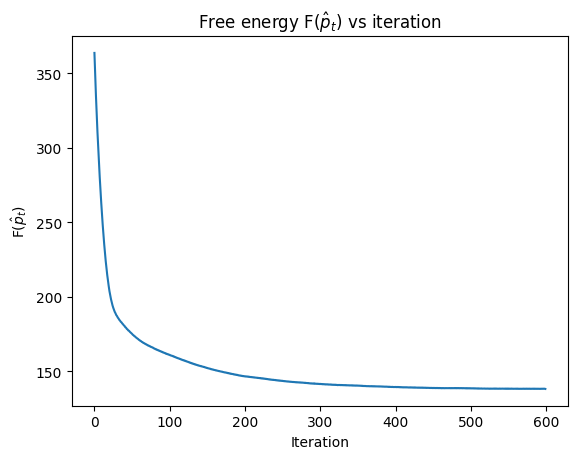

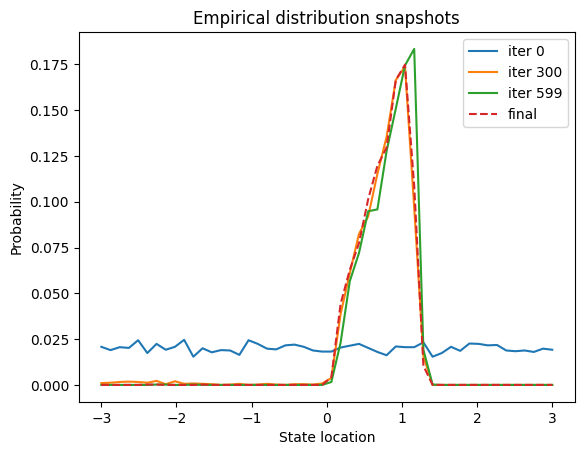

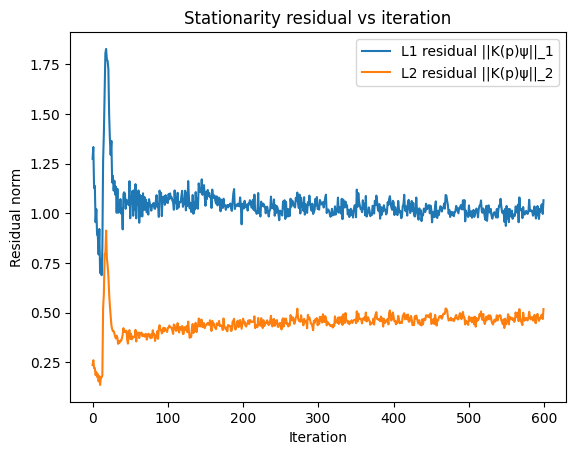

(138.1402903961498, 1.065235641373761, 0.517487837666457)

In [4]:
# We'll run a small NumPy-based mean-field MCMC demo (no JAX dependency)
# and plot: (1) Free energy vs iterations, (2) final empirical distribution,
# (3) stationarity residual ||K(p) psi||_1 vs iterations.

import numpy as np
import math
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

def log_mean(s, t, eps=1e-12):
    s = np.clip(s, eps, None)
    t = np.clip(t, eps, None)
    log_s = np.log(s)
    log_t = np.log(t)
    diff = log_s - log_t
    close = np.abs(diff) < 1e-10
    out = (s - t) / diff
    out[close] = s[close]  # continuous extension
    return out

# Toy setup (mirrors your demo)
M = 50
centers = np.linspace(-3.0, 3.0, M)
p0 = np.ones(M) / M

n_obs = 200
true_center = 0.8
sigma_like = 0.4
y = true_center + 0.5 * rng.standard_normal(n_obs)

# Likelihoods L[i, x] = p_i(x) (unnormalised ok)
dy = y[:, None] - centers[None, :]
L = np.exp(-0.5 * (dy / sigma_like) ** 2)  # shape (n_obs, M)

# Symmetric proposal graph: line with weight w
w = 3.0
A = np.zeros((M, M))
idx = np.arange(M - 1)
A[idx, idx + 1] = w
A[idx + 1, idx] = w

def m_of_p(p):
    return L @ p  # shape (n_obs,)

def log_pi_of_p(p, eps=1e-12):
    m = np.clip(m_of_p(p), eps, None)  # (n_obs,)
    contrib = (L / m[:, None]).sum(axis=0)  # (M,)
    return np.log(np.clip(p0, eps, None)) + contrib  # (M,)

def free_energy(p, eps=1e-12):
    p = np.clip(p, eps, None)
    kld = (p * (np.log(p) - np.log(np.clip(p0, eps, None)))).sum()
    m = np.clip(m_of_p(p), eps, None)
    return kld - np.log(m).sum()

def reversible_rates(p):
    # Metropolis rates wrt pi_p
    lpi = log_pi_of_p(p)
    delta = lpi[None, :] - lpi[:, None]  # logπ(y) - logπ(x)
    factor = np.exp(np.minimum(0.0, delta))
    R = A * factor
    np.fill_diagonal(R, 0.0)
    return R

def mobility(p, R):
    s = p[:, None] * R
    t = p[None, :] * R.T
    W = log_mean(s, t)
    np.fill_diagonal(W, 0.0)
    return W

def psi_of_p(p, eps=1e-12):
    m = np.clip(m_of_p(p), eps, None)
    term = (L / m[:, None]).sum(axis=0)  # (M,)
    return np.log(np.clip(p, eps, None)) - np.log(np.clip(p0, eps, None)) + 1.0 - term

def stationarity_residual(p):
    # r = -K(p) psi = sum_y w_xy (psi_y - psi_x)
    R = reversible_rates(p)
    W = mobility(p, R)
    psi = psi_of_p(p)
    row_sum = W.sum(axis=1)
    r = W @ psi - psi * row_sum
    # Return L1 and L2 norms as discrepancies
    return np.linalg.norm(r, ord=1), np.linalg.norm(r, ord=2)

def step(states):
    # Propose from row-wise categorical proportional to A[x, :]
    logits_rows = A[states]  # shape (N, M)
    # Sample proposals; if a row is all zeros (shouldn't happen), keep same state
    probs_rows = logits_rows / np.clip(logits_rows.sum(axis=1, keepdims=True), 1e-12, None)
    # Categorical sampling
    cum = probs_rows.cumsum(axis=1)
    u = rng.random(states.shape[0])[:, None]
    y = (cum < u).sum(axis=1)  # first index where cum >= u
    # MH accept targeting pi_p (mean-field)
    p_hat = np.bincount(states, minlength=M)
    p_hat = (p_hat + 1e-6) / (states.shape[0] + M * 1e-6)
    lpi = log_pi_of_p(p_hat)
    log_acc = lpi[y] - lpi[states]
    log_u = np.log(rng.random(states.shape[0]))
    accept = log_u < np.minimum(0.0, log_acc)
    new_states = np.where(accept, y, states)
    return new_states

# Run the particle system
N = 5000
states = rng.choice(M, size=N, p=p0)
T = 600  # iterations

F_trace = np.zeros(T)
res_L1 = np.zeros(T)
res_L2 = np.zeros(T)

snapshots = {}
snap_iter = [0, T//2, T-1]

for t in range(T):
    # record diagnostics from current empirical p
    counts = np.bincount(states, minlength=M)
    p_hat = (counts + 1e-6) / (N + M * 1e-6)
    F_trace[t] = free_energy(p_hat)
    l1, l2 = stationarity_residual(p_hat)
    res_L1[t] = l1
    res_L2[t] = l2
    if t in snap_iter:
        snapshots[t] = p_hat.copy()
    # one sweep
    states = step(states)

# Final empirical distribution
counts = np.bincount(states, minlength=M)
p_hat_final = (counts + 1e-6) / (N + M * 1e-6)

# Plot 1: Free energy
plt.figure()
plt.plot(F_trace)
plt.title("Free energy F($\\hat p_t$) vs iteration")
plt.xlabel("Iteration")
plt.ylabel("F($\\hat p_t$)")
plt.show()

# Plot 2: Empirical distribution snapshots
plt.figure()
for t in snap_iter:
    plt.plot(centers, snapshots[t], label=f"iter {t}")
plt.plot(centers, p_hat_final, linestyle="--", label="final")
plt.title("Empirical distribution snapshots")
plt.xlabel("State location")
plt.ylabel("Probability")
plt.legend()
plt.show()

# Plot 3: Stationarity residual norms
plt.figure()
plt.plot(res_L1, label="L1 residual ||K(p)ψ||_1")
plt.plot(res_L2, label="L2 residual ||K(p)ψ||_2")
plt.title("Stationarity residual vs iteration")
plt.xlabel("Iteration")
plt.ylabel("Residual norm")
plt.legend()
plt.show()

# Also print a few numeric summaries
float(F_trace[-1]), float(res_L1[-1]), float(res_L2[-1])
